In [2]:
import pandas as pd
import matplotlib.pyplot as plt



bear_attacks_NA = pd.read_csv("../Datasets/bearsNA.csv")
bear_attacks_global = pd.read_csv("../Datasets/global_brownbear_attacks.csv")



In [3]:
print(bear_attacks_NA.head())
print(bear_attacks_NA.info())

                Name   age  gender        Date Month  Year     Type  \
0   Mary Porterfield   3.0  female  19/05/1901   May  1901     Wild   
1  Wilie Porterfield   5.0    male  19/05/1901   May  1901     Wild   
2  Henry Porterfield   7.0    male  19/05/1901   May  1901     Wild   
3         John Dicht  18.0    male  24/11/1906   Nov  1906     Wild   
4         Baby Laird   1.0     NaN  05/10/1908   Oct  1908  Captive   

                   Location  \
0        Job, West Virginia   
1        Job, West Virginia   
2        Job, West Virginia   
3  Elk County, Pennsylvania   
4           Tucson, Arizona   

                                         Description Type of bear  Hunter  \
0  The children were gathering flowers near their...   Black bear       0   
1  The children were gathering flowers near their...   Black bear       0   
2  The children were gathering flowers near their...   Black bear       0   
3  Thinking the bear was dead, Dicht began skinni...   Black bear       0   
4

In [4]:
print(bear_attacks_global.head(20))
print(bear_attacks_global.info)

       Country/State  NumberofAttacks(2000–2015)  \
0            Romania                         131   
1           Slovakia                          54   
2             Turkey                          54   
3             Alaska                          51   
4   British Columbia                          42   
5            Wyoming                          29   
6             Sweden                          28   
7               Iran                          25   
8            Montana                          25   
9            Alberta                          18   
10           Finland                          17   
11            Greece                          12   
12          Slovenia                          12   
13            Poland                           8   
14           Ukraine                           8   
15             Idaho                           8   
16          Bulgaria                           7   
17    NW Territories                           6   
18          

In [5]:
#Filtering global dataset for Wyoming and Poland 

poland = bear_attacks_global[bear_attacks_global['Country/State'] == 'Poland'].iloc[0]
wyoming = bear_attacks_global[bear_attacks_global['Country/State'] == 'Wyoming'].iloc[0]

In [6]:
#Basic data printing function 
def bear_data(df):
    print("=" * 60)
    print(f"{df['Country/State']} (2000-2015)")
    print("=" * 60)
    print(f"Number of Bears: {df['NumberofBrownBears']}")
    print(f"Number of Attacks: {df['NumberofAttacks(2000–2015)']}")
    print(f"Number of Fatalities: {df['NumberofFatalities(2000–2015)']}")
    print(f"Bear Range (km²): {df['BrownBearRange(km2)']}")
    print(f"Human Density (people/km²): {df['HumanDensity(inhabitants/km2)']}")
    print(f"Bear Density (bears/1000km²): {df['BrownBearDensity(bears/1000km2)']}")
    return 



In [7]:
bear_data(wyoming)

Wyoming (2000-2015)
Number of Bears: 511
Number of Attacks: 29
Number of Fatalities: 5
Bear Range (km²): 27896
Human Density (people/km²): 1.2
Bear Density (bears/1000km²): 18.318


In [8]:
bear_data(poland)

Poland (2000-2015)
Number of Bears: 115
Number of Attacks: 8
Number of Fatalities: 1
Bear Range (km²): 10400
Human Density (people/km²): 75.7
Bear Density (bears/1000km²): 11.058


In [9]:
# Check for non-numeric values in the columns we need
print("Checking for problematic values:")
print(bear_attacks_global[['NumberofBrownBears', 'NumberofAttacks(2000–2015)', 'NumberofFatalities(2000–2015)']].dtypes)
print("\nSample values:")
print(bear_attacks_global[['Country/State', 'NumberofBrownBears', 'NumberofAttacks(2000–2015)']].head(15))

Checking for problematic values:
NumberofBrownBears               object
NumberofAttacks(2000–2015)        int64
NumberofFatalities(2000–2015)     int64
dtype: object

Sample values:
       Country/State NumberofBrownBears  NumberofAttacks(2000–2015)
0            Romania               6000                         131
1           Slovakia               1000                          54
2             Turkey               4000                          54
3             Alaska              32000                          51
4   British Columbia              15000                          42
5            Wyoming                511                          29
6             Sweden               2900                          28
7               Iran            unknown                          25
8            Montana               1105                          25
9            Alberta                691                          18
10           Finland               1700                          17
1

In [10]:
def calculate_metrics(region_data):
    num_bears = float(region_data['NumberofBrownBears'])
    num_attacks = float(region_data['NumberofAttacks(2000–2015)'])
    num_fatalities = float(region_data['NumberofFatalities(2000–2015)'])

    # Calculate rates
    attack_per_bear = (num_attacks / num_bears) * 100 if num_bears > 0 else 0
    fatality_rate = (num_fatalities / num_attacks) * 100 if num_attacks > 0 else 0
    fatality_per_bear = (num_fatalities / num_bears) * 100 if num_bears > 0 else 0                                                
    
    return {
        'num_bears': num_bears,
        'num_attacks': num_attacks,
        'num_fatalities': num_fatalities,
        'attacks_per_bear_percent': attack_per_bear,
        'fatality_rate_percent': fatality_rate,
        'fatalities_per_bear_percent': fatality_per_bear
    }
    

wyoming_metrics = calculate_metrics(wyoming)
poland_metrics = calculate_metrics(poland)

# Create comparison table
comparison_df = pd.DataFrame({
    'Metric': [
        'Number of Bears',
        'Number of Attacks (2000-2015)',
        'Number of Fatalities',
        'Attacks per Bear (%)',
        'Fatality Rate (% of attacks)',
        'Fatalities per Bear (%)'
    ],
    'Wyoming': [
        wyoming_metrics['num_bears'],
        wyoming_metrics['num_attacks'],
        wyoming_metrics['num_fatalities'],
        f"{wyoming_metrics['attacks_per_bear_percent']:.3f}%",
        f"{wyoming_metrics['fatality_rate_percent']:.1f}%",
        f"{wyoming_metrics['fatalities_per_bear_percent']:.3f}%"
    ],
    'Poland': [
        poland_metrics['num_bears'],
        poland_metrics['num_attacks'],
        poland_metrics['num_fatalities'],
        f"{poland_metrics['attacks_per_bear_percent']:.3f}%",
        f"{poland_metrics['fatality_rate_percent']:.1f}%",
        f"{poland_metrics['fatalities_per_bear_percent']:.3f}%"
    ]
})

In [11]:
print(comparison_df)

                          Metric Wyoming  Poland
0                Number of Bears   511.0   115.0
1  Number of Attacks (2000-2015)    29.0     8.0
2           Number of Fatalities     5.0     1.0
3           Attacks per Bear (%)  5.675%  6.957%
4   Fatality Rate (% of attacks)   17.2%   12.5%
5        Fatalities per Bear (%)  0.978%  0.870%


In [12]:
print(f"Total records: {len(bear_attacks_NA)}")
print(f"\nColumns: {bear_attacks_NA.columns.tolist()}")
print(bear_attacks_NA.head(-3))

Total records: 166

Columns: ['Name', ' age', 'gender', 'Date', 'Month', 'Year', 'Type', 'Location', 'Description', 'Type of bear', 'Hunter', 'Grizzly', 'Hikers', 'Only one killed', 'Latitude', 'Longitude']
                  Name   age  gender        Date Month  Year     Type  \
0     Mary Porterfield   3.0  female  19/05/1901   May  1901     Wild   
1    Wilie Porterfield   5.0    male  19/05/1901   May  1901     Wild   
2    Henry Porterfield   7.0    male  19/05/1901   May  1901     Wild   
3           John Dicht  18.0    male  24/11/1906   Nov  1906     Wild   
4           Baby Laird   1.0     NaN  05/10/1908   Oct  1908  Captive   
..                 ...   ...     ...         ...   ...   ...      ...   
158     Patrick Cooper  16.0    male  18/06/2017   Jun  2017     Wild   
159       Erin Johnson  27.0  female  19/06/2017   Jun  2017     Wild   
160        Mike Soltis  44.0    male  19/06/2018   Jun  2018     Wild   
161      Aaron Gibbons  31.0    male  03/07/2018   Jul  2018   

In [13]:
ba_NA = bear_attacks_NA.copy()
ba_NA_f2000 = ba_NA.loc[(ba_NA['Year'] >= 2000) &
                        (ba_NA['Year'] < 2016)]
ba_NA_f2000

,Name,age,gender,Date,Month,Year,Type,Location,Description,Type of bear,Hunter,Grizzly,Hikers,Only one killed,Latitude,Longitude
112,Glenda Ann Bradley,50.000000,female,21/05/2000,May,2000,Wild,"Great Smoky Mountains National Park, Tennessee",Bradley was attacked and partially consumed by...,Black bear,0,0,0,1,35.634220,-83.402366
113,Mary Beth Miller,24.000000,female,02/07/2000,Jul,2000,Wild,"near Valcartier, Quebec",Miller was attacked while on a biathlon traini...,Black bear,0,0,0,1,NaN,NaN
114,George Tullos,41.000000,male,14/07/2000,Jul,2000,Wild,"Hyder, Alaska",Tullos' partially consumed body was found at a...,Brown bear,0,0,0,1,55.917086,-130.027254
115,Kyle Harry,18.000000,male,03/06/2001,Jun,2001,Wild,"near Yellowknife, Northwest Territories",Harry was attacked while with a group at a rur...,Black bear,0,0,0,1,NaN,NaN
116,Adelia Maestras Trujillo,93.000000,female,18/08/2001,Aug,2001,Wild,"Mora, New Mexico",A bear broke through a glass pane to gain entr...,Black bear,0,0,0,1,35.972232,-104.913222
117,Timothy Hilston,50.000000,male,30/10/2001,Oct,2001,Wild,"near Ovando, Montana",Hilston was attacked as he field dressed an el...,Brown bear,0,0,0,1,NaN,NaN
118,Ester Schwimmer,0.416667,female,19/08/2002,Aug,2002,Wild,"Fallsburg, New York","A bear knocked Schwimmer from her stroller, wh...",Black bear,0,0,0,1,41.732036,-74.601271
119,Christopher Bayduza,31.000000,male,01/09/2002,Sep,2002,Wild,"near Fort Nelson, British Columbia","After going for a walk behind a trailer, Baydu...",Black bear,0,0,0,1,NaN,NaN
120,Maurice Malenfant,77.000000,male,29/09/2002,Sep,2002,Wild,"Saint-Zénon-du-Lac-Humqui, Quebec",Malenfant was attacked in his campsite in the ...,Black bear,0,0,0,1,48.307193,-67.579886
121,Amie Huguenard,37.000000,female,05/10/2003,Oct,2003,Wild,"Katmai National Park, Alaska",Treadwell and Huguenard's corpses were found b...,Brown bear,0,1,0,0,58.504984,-155.089623


In [14]:
# Check what's in the Type column
print("Attack Types available:")
print(bear_attacks_NA['Type'].unique())
print(f"\nCount by Type:")
print(bear_attacks_NA['Type'].value_counts())

Attack Types available:
['Wild' 'Captive']

Count by Type:
Type
Wild       138
Captive     28
Name: count, dtype: int64


In [15]:
wyoming_attacks_2 = ba_NA_f2000[ba_NA_f2000['Location'].str.contains('Wyoming', case = False, na = False)]
print(wyoming_attacks_2)
print(len(wyoming_attacks_2))

                    Name   age gender        Date Month  Year  Type  \
140    Erwin Frank Evert  70.0   male  17/06/2010   Jun  2010  Wild   
144      Brian Matayoshi  57.0   male  06/07/2011   Jul  2011  Wild   
146         John Wallace  59.0   male  24/08/2011   Aug  2011  Wild   
151  Adam Thomas Stewart  31.0   male  04/09/2014   Sep  2014  Wild   
156         Lance Crosby  63.0   male  07/08/2015   Aug  2015  Wild   

                                   Location  \
140       Shoshone National Forest, Wyoming   
144      Yellowstone National Park, Wyoming   
146      Yellowstone National Park, Wyoming   
151  Bridger-Teton National Forest, Wyoming   
156      Yellowstone National Park, Wyoming   

                                           Description Type of bear  Hunter  \
140  Evert, a field botanist, was mauled by a grizz...   Brown bear       0   
144  Matayoshi and his wife were hiking the Wapiti ...   Brown bear       0   
146  Wallace's remains were found by hikers on the ..

In [16]:
wyoming_attacks_2['Description'] 

140    Evert, a field botanist, was mauled by a grizz...
144    Matayoshi and his wife were hiking the Wapiti ...
146    Wallace's remains were found by hikers on the ...
151    Stewart was conducting research alone in the B...
156    Crosby, an employee at a medical clinic in the...
Name: Description, dtype: object

In [17]:
# Print the description at index 0
print(wyoming_attacks_2.loc[156, 'Description'])

Crosby, an employee at a medical clinic in the park, was reported missing when he did not report for work. A park ranger found his body in a popular off-trail area less than a mile (1 600 m) from Elephant Back Loop Trail, an area he was known to frequent. His body was partially consumed and covered. Puncture wounds on his arms indicated he had tried to defend himself. Based on the presence of a sow grizzly and a cub in the area, the sow was deemed responsible for the attack. The sow was captured and killed after it was found to be the bear that killed Crosby.[27][28] There were public appeals to not kill the sow, but the park superintendent decided there was a risk the sow might kill again; based on July 6, 2011 and August 24, 2011 killings in the park, where another sow was present at both those killings.[29]


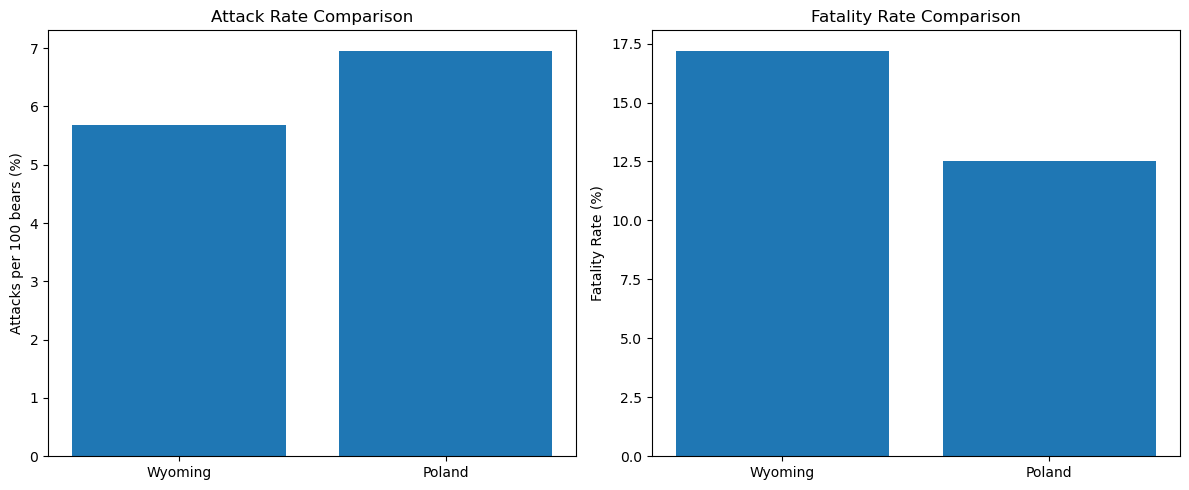

In [18]:
# Create a side-by-side bar chart comparing Wyoming vs Poland

metrics_data = {
    'Wyoming': [5.675, 17.2],
    'Poland': [6.957, 12.5]
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Attack rate per bear
axes[0].bar(metrics_data.keys(), [metrics_data[k][0] for k in metrics_data])
axes[0].set_ylabel('Attacks per 100 bears (%)')
axes[0].set_title('Attack Rate Comparison')

# Fatality rate
axes[1].bar(metrics_data.keys(), [metrics_data[k][1] for k in metrics_data])
axes[1].set_ylabel('Fatality Rate (%)')
axes[1].set_title('Fatality Rate Comparison')

plt.tight_layout()
plt.show()

In [19]:
print(bear_data(poland))

Poland (2000-2015)
Number of Bears: 115
Number of Attacks: 8
Number of Fatalities: 1
Bear Range (km²): 10400
Human Density (people/km²): 75.7
Bear Density (bears/1000km²): 11.058
None


In [20]:
print(bear_data(wyoming))

Wyoming (2000-2015)
Number of Bears: 511
Number of Attacks: 29
Number of Fatalities: 5
Bear Range (km²): 27896
Human Density (people/km²): 1.2
Bear Density (bears/1000km²): 18.318
None


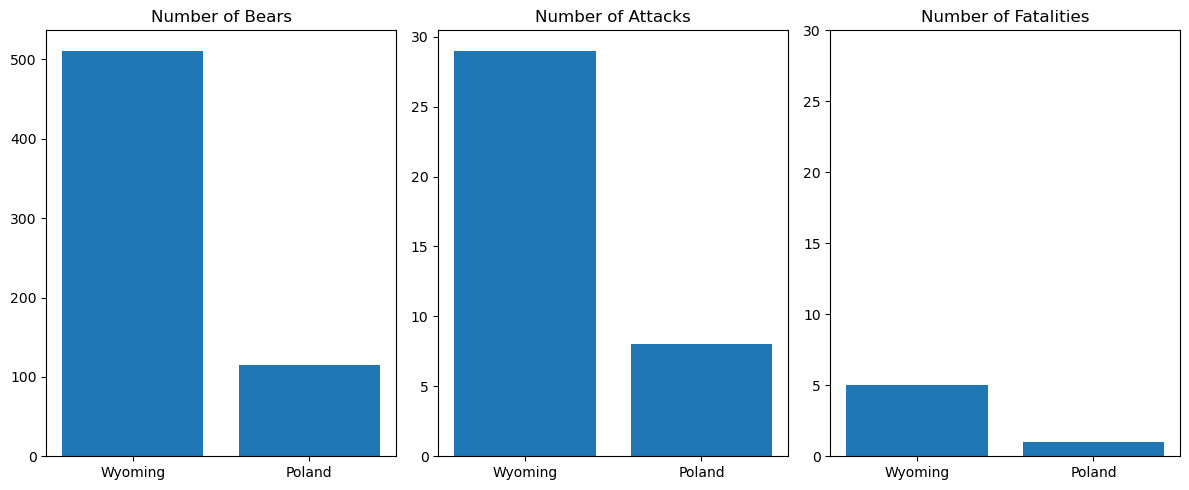

In [21]:
#Slide 1 RAw comparision 
fig, axes = plt.subplots(1,3 , figsize=(12, 5))

metrics_data = {
    'Wyoming': [511, 29, 5],
    'Poland': [ 115 , 8, 1]
}

#Number of bears
axes[0].bar(metrics_data.keys(), [metrics_data[k][0] for k in metrics_data])
axes[0].set_title('Number of Bears')


# Attack rate per bear
axes[1].bar(metrics_data.keys(), [metrics_data[k][1] for k in metrics_data])
axes[1].set_title('Number of Attacks')

# Fatality rate
axes[2].bar(metrics_data.keys(), [metrics_data[k][2] for k in metrics_data])
axes[2].set_title('Number of Fatalities')
axes[2].set_ylim(0,30)

plt.tight_layout()
plt.show()


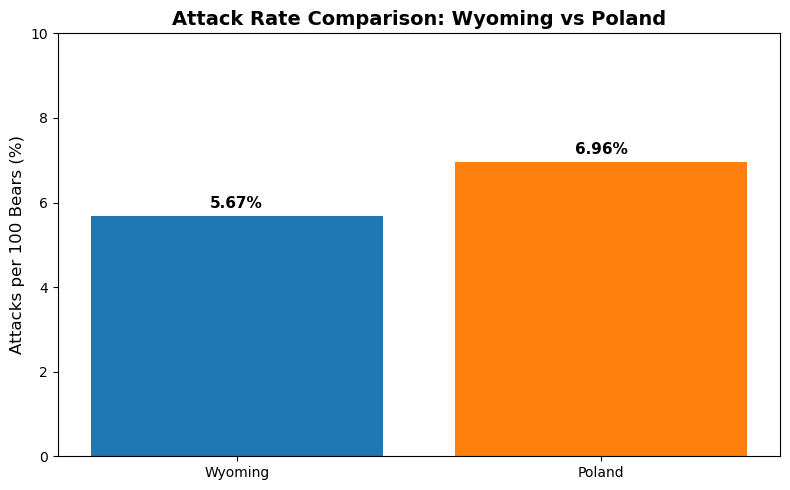

In [22]:
#Slide 2 comparing attack rates 

comp_indexed = comparison_df.set_index('Metric')
rate_wyoming = float(comp_indexed.loc['Attacks per Bear (%)', 'Wyoming'].strip('%'))
rate_poland = float(comp_indexed.loc['Attacks per Bear (%)', 'Poland'].strip('%'))

fig, ax = plt.subplots(figsize=(8, 5))

# Bar chart
ax.bar(['Wyoming', 'Poland'], [rate_wyoming, rate_poland], color=['#1f77b4', '#ff7f0e'])
ax.set_ylabel('Attacks per 100 Bears (%)', fontsize=12)
ax.set_title('Attack Rate Comparison: Wyoming vs Poland', fontsize=14, fontweight='bold')
ax.set_ylim(0, 10)

# Add value labels on bars
for i, (region, value) in enumerate(zip(['Wyoming', 'Poland'], [rate_wyoming, rate_poland])):
    ax.text(i, value + 0.2, f'{value:.2f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

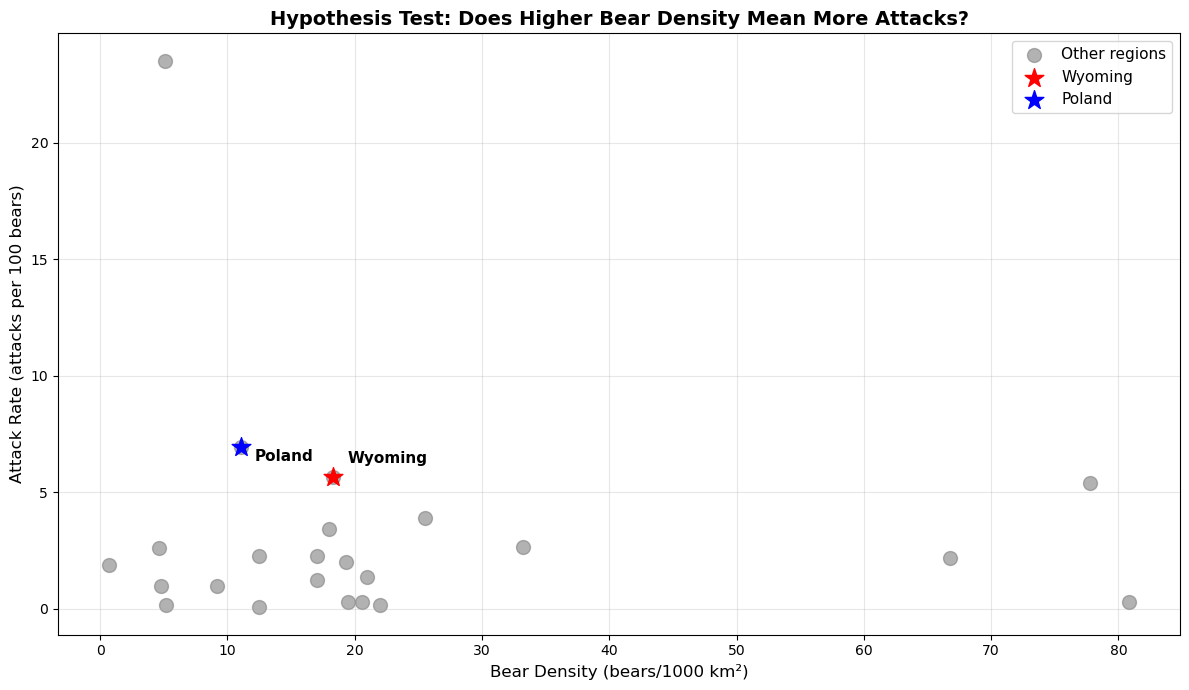

In [23]:
# SLIDE 3: Broader Context - Bear Density vs Attack Rate (All Regions)

def create_slide3():
    # Calculate attack rate for all regions
    global_data = bear_attacks_global.copy()
    global_data['NumberofBrownBears'] = pd.to_numeric(
        global_data['NumberofBrownBears'], errors='coerce'
    )
    global_data['NumberofAttacks(2000–2015)'] = pd.to_numeric(
        global_data['NumberofAttacks(2000–2015)'], errors='coerce'
    )
    global_data['BrownBearDensity(bears/1000km2)'] = pd.to_numeric(
        global_data['BrownBearDensity(bears/1000km2)'], errors='coerce'
    )
    
    # Calculate attack rate per 100 bears
    global_data['AttackRate'] = (
        global_data['NumberofAttacks(2000–2015)'] / global_data['NumberofBrownBears'] * 100
    )
    
    # Remove rows with NaN values
    global_data_clean = global_data.dropna(subset=['BrownBearDensity(bears/1000km2)', 'AttackRate'])
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Plot all regions in gray
    ax.scatter(
        global_data_clean['BrownBearDensity(bears/1000km2)'],
        global_data_clean['AttackRate'],
        s=100, alpha=0.6, color='gray', label='Other regions'
    )
    
    # Highlight Wyoming and Poland
    wyoming_data = global_data_clean[global_data_clean['Country/State'] == 'Wyoming']
    poland_data = global_data_clean[global_data_clean['Country/State'] == 'Poland']
    
    if not wyoming_data.empty:
        ax.scatter(
            wyoming_data['BrownBearDensity(bears/1000km2)'],
            wyoming_data['AttackRate'],
            s=200, color='red', marker='*', label='Wyoming', zorder=5
        )
        ax.annotate(
            'Wyoming',
            (wyoming_data['BrownBearDensity(bears/1000km2)'].values[0],
             wyoming_data['AttackRate'].values[0]),
            xytext=(10, 10), textcoords='offset points', fontsize=11, fontweight='bold'
        )
    
    if not poland_data.empty:
        ax.scatter(
            poland_data['BrownBearDensity(bears/1000km2)'],
            poland_data['AttackRate'],
            s=200, color='blue', marker='*', label='Poland', zorder=5
        )
        ax.annotate(
            'Poland',
            (poland_data['BrownBearDensity(bears/1000km2)'].values[0],
             poland_data['AttackRate'].values[0]),
            xytext=(10, -10), textcoords='offset points', fontsize=11, fontweight='bold'
        )
    
    ax.set_xlabel('Bear Density (bears/1000 km²)', fontsize=12)
    ax.set_ylabel('Attack Rate (attacks per 100 bears)', fontsize=12)
    ax.set_title('Hypothesis Test: Does Higher Bear Density Mean More Attacks?', 
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

create_slide3()

/var/folders/8p/ym97qvfj5p3cqhq47g7vmvgm0000gn/T/ipykernel_1700/2934100909.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wyoming_wild['Month'] = pd.Categorical(wyoming_wild['Month'], categories=month_order, ordered=True)


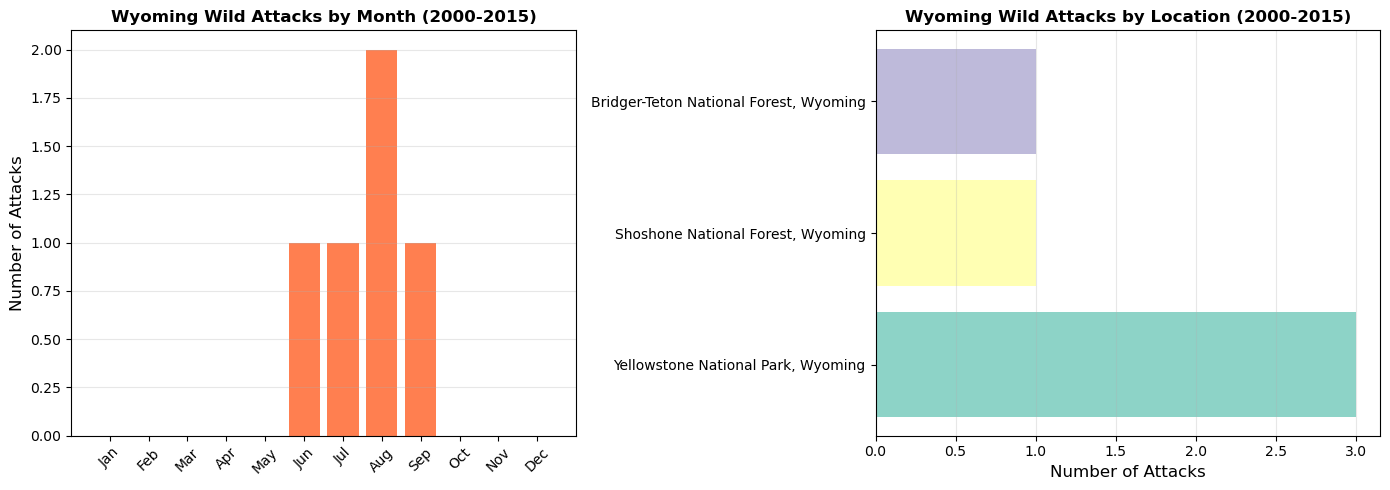

Total Wyoming wild attacks (2000-2015): 5
Average per year: 0.33


In [24]:
# SLIDE 4: Wyoming Specifics - Attacks by Month and Location

def create_slide4():
    # Use the Wyoming wild attacks already filtered
    wyoming_wild = ba_NA_f2000[ba_NA_f2000['Location'].str.contains('Wyoming', case=False, na=False)]
    
    # Count attacks by month
    month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    wyoming_wild['Month'] = pd.Categorical(wyoming_wild['Month'], categories=month_order, ordered=True)
    attacks_by_month = wyoming_wild['Month'].value_counts().sort_index()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Subplot 1: Attacks by month
    axes[0].bar(range(len(attacks_by_month)), attacks_by_month.values, color='coral')
    axes[0].set_xticks(range(len(attacks_by_month)))
    axes[0].set_xticklabels(attacks_by_month.index, rotation=45)
    axes[0].set_ylabel('Number of Attacks', fontsize=12)
    axes[0].set_title('Wyoming Wild Attacks by Month (2000-2015)', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Subplot 2: Attacks by location
    location_counts = wyoming_wild['Location'].value_counts()
    colors_map = plt.cm.Set3(range(len(location_counts)))
    axes[1].barh(range(len(location_counts)), location_counts.values, color=colors_map)
    axes[1].set_yticks(range(len(location_counts)))
    axes[1].set_yticklabels(location_counts.index, fontsize=10)
    axes[1].set_xlabel('Number of Attacks', fontsize=12)
    axes[1].set_title('Wyoming Wild Attacks by Location (2000-2015)', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Total Wyoming wild attacks (2000-2015): {len(wyoming_wild)}")
    print(f"Average per year: {len(wyoming_wild)/15:.2f}")

create_slide4()

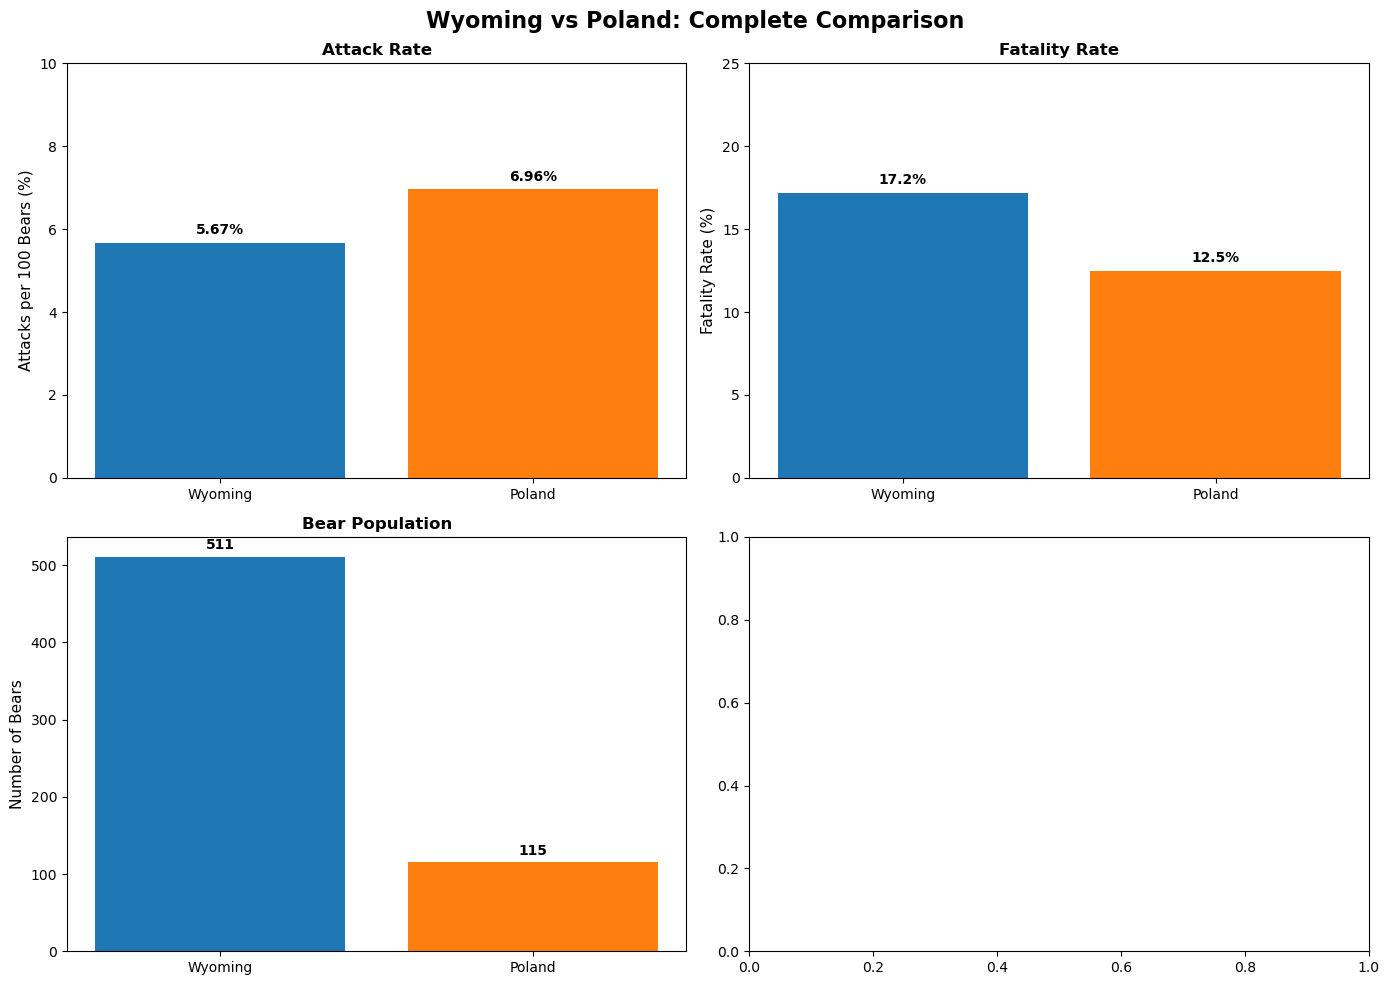

In [26]:
# SLIDE 5: Conclusion Summary

def create_slide5():
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    regions = ['Wyoming', 'Poland']
    bears = [511, 115]
    attack_rates = [5.675, 6.957]
    fatality_rates = [17.2, 12.5]
    
    # Attack rate
    axes[0, 0].bar(regions, attack_rates, color=['#1f77b4', '#ff7f0e'])
    axes[0, 0].set_ylabel('Attacks per 100 Bears (%)', fontsize=11)
    axes[0, 0].set_title('Attack Rate', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylim(0, 10)
    for i, v in enumerate(attack_rates):
        axes[0, 0].text(i, v + 0.2, f'{v:.2f}%', ha='center', fontweight='bold')
    
    # Fatality rate
    axes[0, 1].bar(regions, fatality_rates, color=['#1f77b4', '#ff7f0e'])
    axes[0, 1].set_ylabel('Fatality Rate (%)', fontsize=11)
    axes[0, 1].set_title('Fatality Rate', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylim(0, 25)
    for i, v in enumerate(fatality_rates):
        axes[0, 1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
    
    # Bear population
    axes[1, 0].bar(regions, bears, color=['#1f77b4', '#ff7f0e'])
    axes[1, 0].set_ylabel('Number of Bears', fontsize=11)
    axes[1, 0].set_title('Bear Population', fontsize=12, fontweight='bold')
    for i, v in enumerate(bears):
        axes[1, 0].text(i, v + 10, str(v), ha='center', fontweight='bold')
    

    
    plt.suptitle('Wyoming vs Poland: Complete Comparison', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

create_slide5()